# eda para classificação de faixa de preço de celulares

**objetivo:** analisar um conjunto de dados com especificações técnicas de celulares para entender quais atributos parecem ter maior relação com a faixa de preço de cada aparelho.

a variável alvo é `price_range`, que representa um problema de classificação multiclasse:

- `0 = baixo custo`
- `1 = médio custo`
- `2 = alto custo`
- `3 = muito alto custo`


## glossário das variáveis

as descrições abaixo foram interpretadas a partir dos nomes das variáveis e da documentação usual desse dataset.

- `battery_power`: capacidade da bateria do celular
- `blue`: indica se o aparelho possui bluetooth (`0 = não`, `1 = sim`)
- `clock_speed`: velocidade de processamento do aparelho, normalmente associada ao clock do processador
- `dual_sim`: indica se o celular suporta dois chips SIM (`0 = não`, `1 = sim`)
- `fc`: resolução da câmera frontal em megapixels
- `four_g`: indica se o aparelho possui suporte a rede 4G (`0 = não`, `1 = sim`)
- `int_memory`: memória interna disponível para armazenamento
- `m_dep`: espessura ou profundidade do aparelho
- `mobile_wt`: peso do celular
- `n_cores`: quantidade de núcleos do processador
- `pc`: resolução da câmera principal em megapixels
- `px_height`: altura da resolução da tela em pixels
- `px_width`: largura da resolução da tela em pixels
- `ram`: memória RAM do aparelho, uma das variáveis mais relevantes para desempenho
- `sc_h`: altura da tela do dispositivo
- `sc_w`: largura da tela do dispositivo
- `talk_time`: tempo máximo de conversação com a bateria carregada
- `three_g`: indica se o aparelho possui suporte a rede 3G (`0 = não`, `1 = sim`).
- `touch_screen`: indica se o celular possui tela sensível ao toque (`0 = não`, `1 = sim`)
- `wifi`: indica se o aparelho possui conectividade Wi-Fi (`0 = não`, `1 = sim`)
- `price_range`: variável alvo do projeto, que representa a faixa de preço do celular

### observação
as variáveis binárias do dataset usam valores `0` e `1` para indicar ausência ou presença de determinados recursos no aparelho

### feature engineering

- `screen_area`: área física aproximada da tela, calculada a partir de sc_h * sc_w
- `pixel_area`: quantidade aproximada de pixels da resolução da tela, calculada a partir de px_height * px_width
- `camera_total`: soma da resolução da câmera frontal com a câmera principal, calculada como fc + pc
- `connectivity_score`: quantidade de recursos de conectividade presentes no aparelho, calculada pela soma de blue, dual_sim, four_g, three_g e wifi

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap


dark_palette = [
    "#4B000F",
    "#7A001F",
    "#A83246",
    "#C45A6A",
    "#2B2D42",
    "#1F1F2E",
    "#8D99AE",
    "#D8DEE9"
]

sns.set_theme(
    style="whitegrid",
    palette=dark_palette,
    font_scale=1.05
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

cmap = sns.diverging_palette(250, 10, as_cmap=True)
cor = LinearSegmentedColormap.from_list(
    "cor",
    ["#2B2D42", "#8D99AE", "#F4F1EE", "#C45A6A", "#7A001F"],
    N=256
)

class_labels = {
    0: "Baixo",
    1: "Médio",
    2: "Alto",
    3: "Muito Alto"
}

ordered_labels = ["Baixo", "Médio", "Alto", "Muito Alto"]


## carregamento dos dados

nesta etapa, carregamos o arquivo `train.csv`, que será usado ao longo de toda a análise exploratória


In [5]:
df = pd.read_csv("../data/train.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## visão geral do dataset

In [6]:
display(df.head())
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Dimensões do dataset: 2000 linhas e 21 colunas


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


### valores nulos, duplicatas e tipos das variáveis

além da visão descritiva, também vale verificar se existem valores ausentes, registros duplicados e quantos valores distintos aparecem em cada coluna

In [9]:
summary_df = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_nulos": df.isnull().sum(),
    "valores_unicos": df.nunique()
})

display(summary_df)
print(f"Total de valores nulos no dataset: {df.isnull().sum().sum()}")
print(f"Total de linhas duplicadas: {df.duplicated().sum()}")

,tipo,valores_nulos,valores_unicos
battery_power,int64,0,1094
blue,int64,0,2
clock_speed,float64,0,26
dual_sim,int64,0,2
fc,int64,0,20
four_g,int64,0,2
int_memory,int64,0,63
m_dep,float64,0,10
mobile_wt,int64,0,121
n_cores,int64,0,8


Total de valores nulos no dataset: 0
Total de linhas duplicadas: 0


## análise da variável alvo

como este é um problema de classificação multiclasse, faz sentido começar avaliando a distribuição de `price_range`. essa etapa ajuda a verificar se as classes estão equilibradas e se o conjunto de dados favorece uma comparação justa entre modelos

,Classe,Contagem,Percentual (%)
0,Baixo,500,25.0
1,Médio,500,25.0
2,Alto,500,25.0
3,Muito Alto,500,25.0


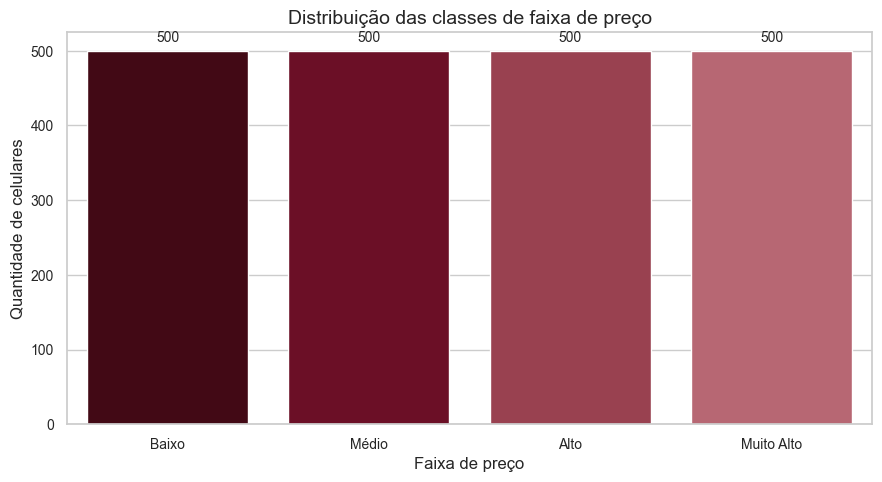

As classes parecem bem balanceadas, com proporções bastante próximas entre si.


In [10]:
target_counts = df["price_range"].value_counts().sort_index()
target_percent = (
    df["price_range"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Classe": [class_labels[idx] for idx in target_counts.index],
    "Contagem": target_counts.values,
    "Percentual (%)": target_percent.values
})

display(target_summary)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=target_summary,
    x="Classe",
    y="Contagem",
    hue="Classe",
    palette=dark_palette[:4],
    dodge=False,
    legend=False
)

for i, value in enumerate(target_summary["Contagem"]):
    ax.text(i, value + 8, str(value), ha="center", va="bottom", fontsize=10)

ax.set_title("Distribuição das classes de faixa de preço")
ax.set_xlabel("Faixa de preço")
ax.set_ylabel("Quantidade de celulares")
plt.tight_layout()
plt.show()

if target_percent.max() - target_percent.min() <= 5:
    print("As classes parecem bem balanceadas, com proporções bastante próximas entre si.")
else:
    print("Existe algum nível de desbalanceamento entre as classes, o que merece atenção na modelagem.")

## análise das variáveis numéricas

análise das variáveis numéricas centrais do problema. o objetivo é entender a distribuição dos dados, a dispersão e possíveis diferenças de escala entre os atributos

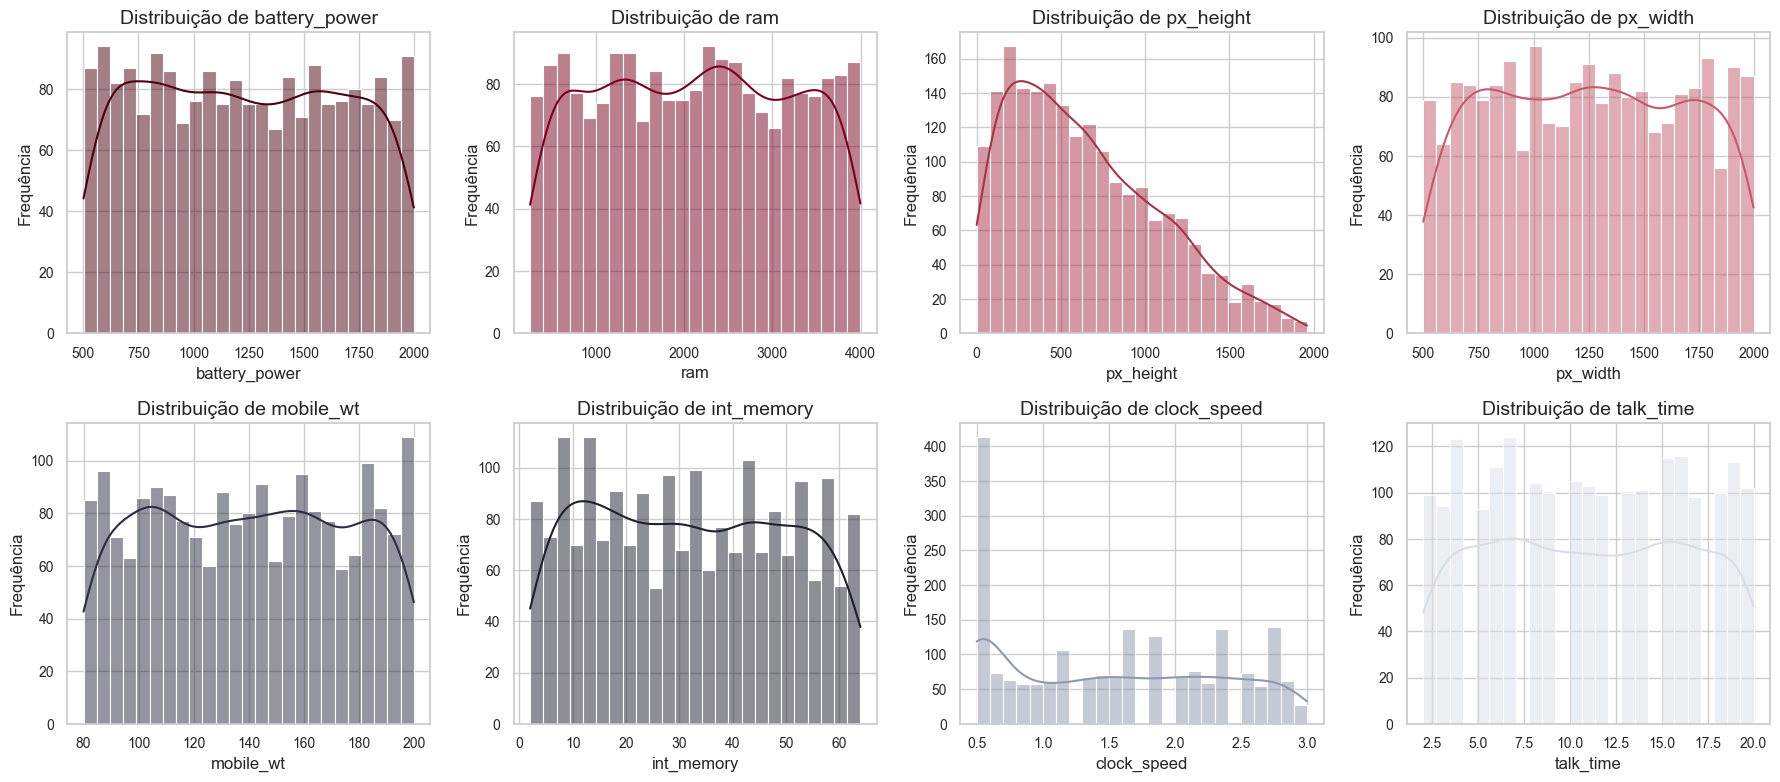

In [11]:
numeric_features = [
    "battery_power",
    "ram",
    "px_height",
    "px_width",
    "mobile_wt",
    "int_memory",
    "clock_speed",
    "talk_time"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        bins=25,
        kde=True,
        color=dark_palette[i % len(dark_palette)],
        ax=axes[i]
    )
    axes[i].set_title(f"Distribuição de {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

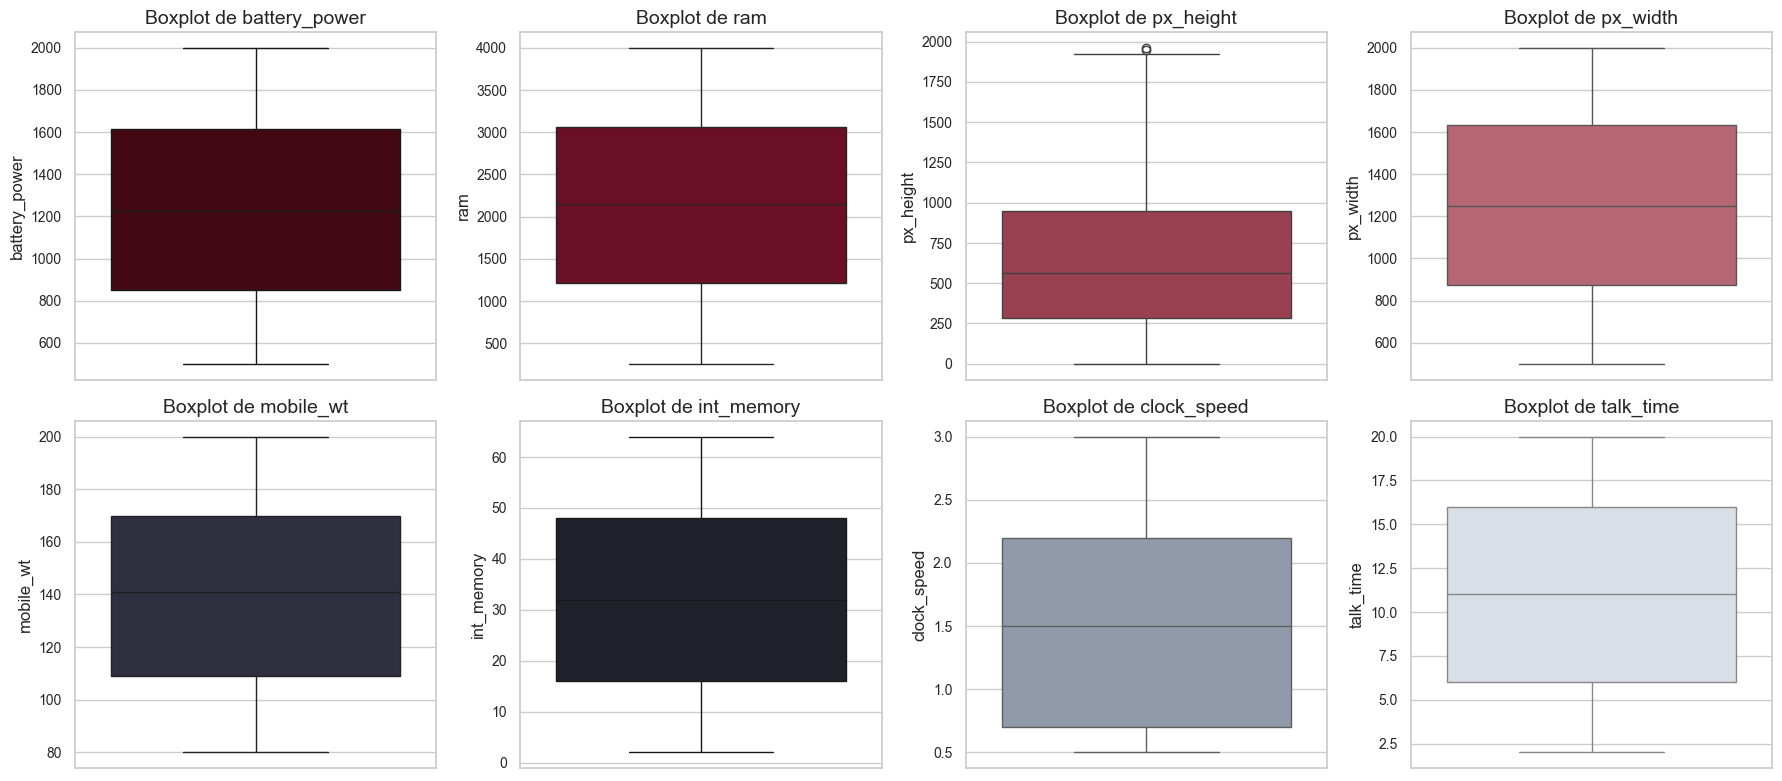

In [12]:
numeric_features = [
    "battery_power",
    "ram",
    "px_height",
    "px_width",
    "mobile_wt",
    "int_memory",
    "clock_speed",
    "talk_time"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(
        data=df,
        y=feature,
        color=dark_palette[i % len(dark_palette)],
        ax=axes[i]
    )
    axes[i].set_title(f"Boxplot de {feature}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

## relação das variáveis com a faixa de preço

análise de como algumas variáveis se comportam em cada faixa de preço. boxplots para visualizar diferenças de mediana, dispersão e sobreposição entre classes

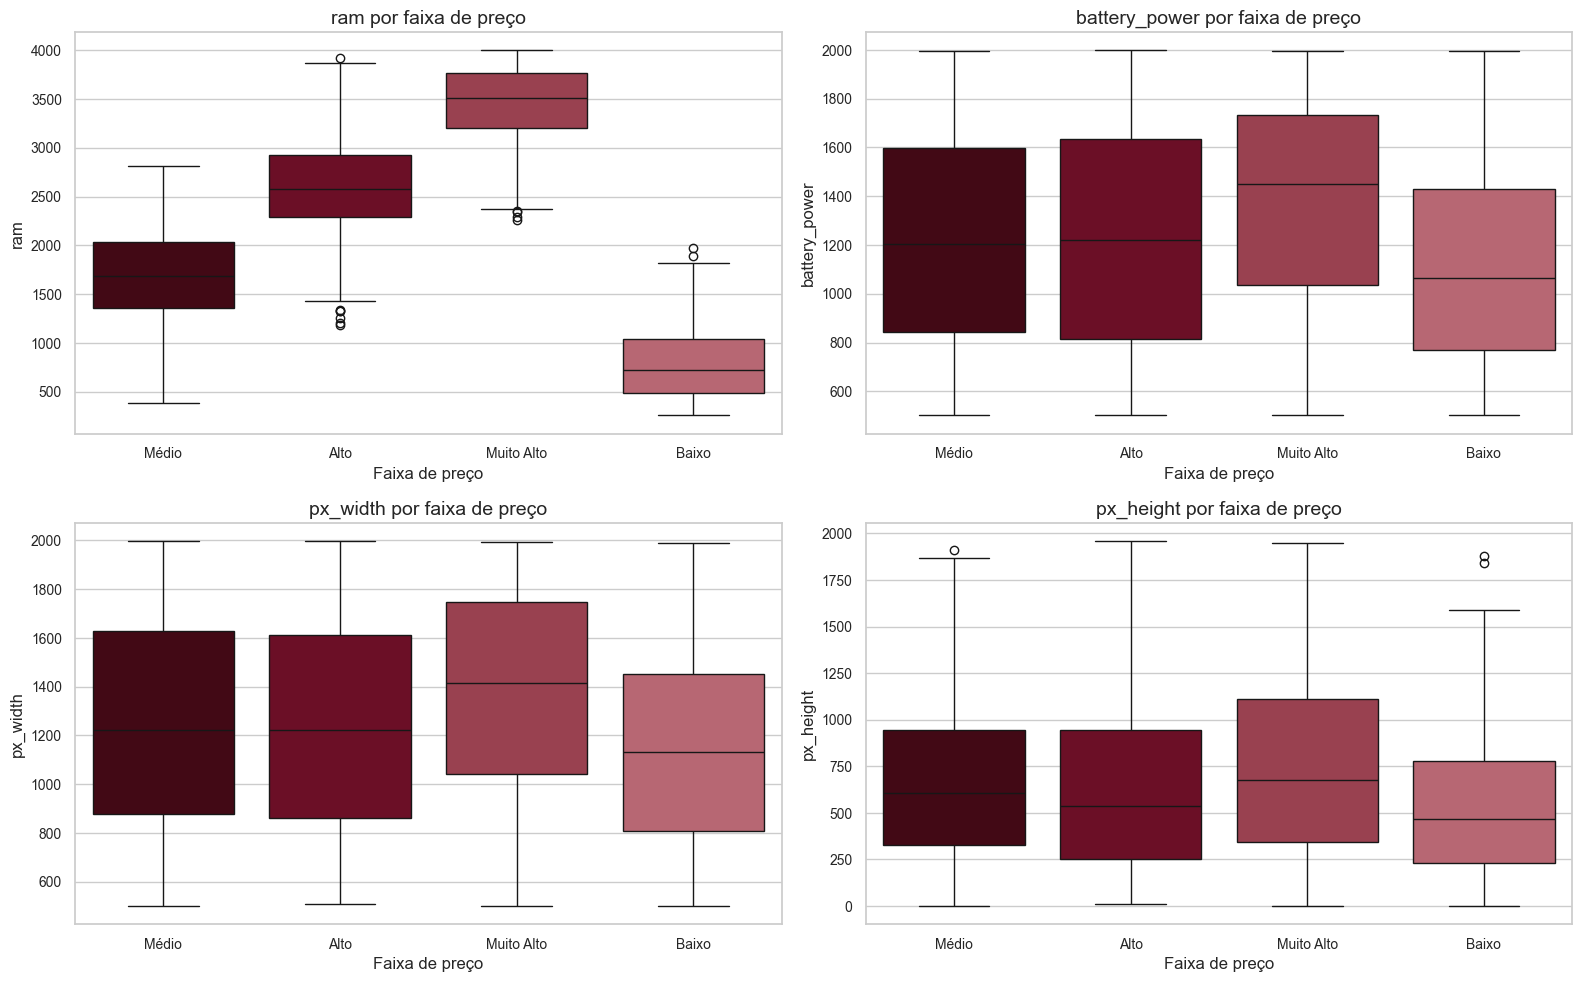

In [13]:
df_eda = df.copy()
df_eda["price_range_label"] = df_eda["price_range"].map(class_labels)

features_to_compare = ["ram", "battery_power", "px_width", "px_height"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_compare):
    sns.boxplot(
        data=df_eda,
        x="price_range_label",
        y=feature,
        hue="price_range_label",
        palette=dark_palette[:4],
        dodge=False,
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} por faixa de preço")
    axes[i].set_xlabel("Faixa de preço")
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

esses gráficos ajudam a perceber quais atributos se separam melhor entre as classes. em geral, quanto menor a sobreposição entre os grupos, maior tende a ser o potencial preditivo da variável

## variáveis derivadas para análise

além das colunas originais, também é útil criar algumas variáveis derivadas para enriquecer a leitura exploratória

- `screen_area`: área física aproximada da tela.
- `pixel_area`: quantidade aproximada de pixels da resolução.
- `camera_total`: soma da câmera frontal com a câmera principal.
- `connectivity_score`: total de recursos de conectividade presentes no aparelho.

In [14]:
df_eda["screen_area"] = df_eda["sc_h"] * df_eda["sc_w"]
df_eda["pixel_area"] = df_eda["px_height"] * df_eda["px_width"]
df_eda["camera_total"] = df_eda["fc"] + df_eda["pc"]
df_eda["connectivity_score"] = df_eda[["blue", "dual_sim", "four_g", "three_g", "wifi"]].sum(axis=1)

derived_features = ["screen_area", "pixel_area", "camera_total", "connectivity_score"]

display(df_eda[derived_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
screen_area,2000.0,80.2570,76.824156,0.0,19.0,55.0,121.50,342.0
pixel_area,2000.0,905260.0535,829762.496935,0.0,263200.5,601359.0,1359027.25,3886306.0
camera_total,2000.0,14.2260,9.463916,0.0,7.0,14.0,21.00,39.0
connectivity_score,2000.0,2.7945,1.196238,0.0,2.0,3.0,4.00,5.0


a análise abaixo ajuda a verificar se essas variáveis derivadas reforçam padrões já observados nas features originais ou se acrescentam novas pistas sobre a faixa de preço

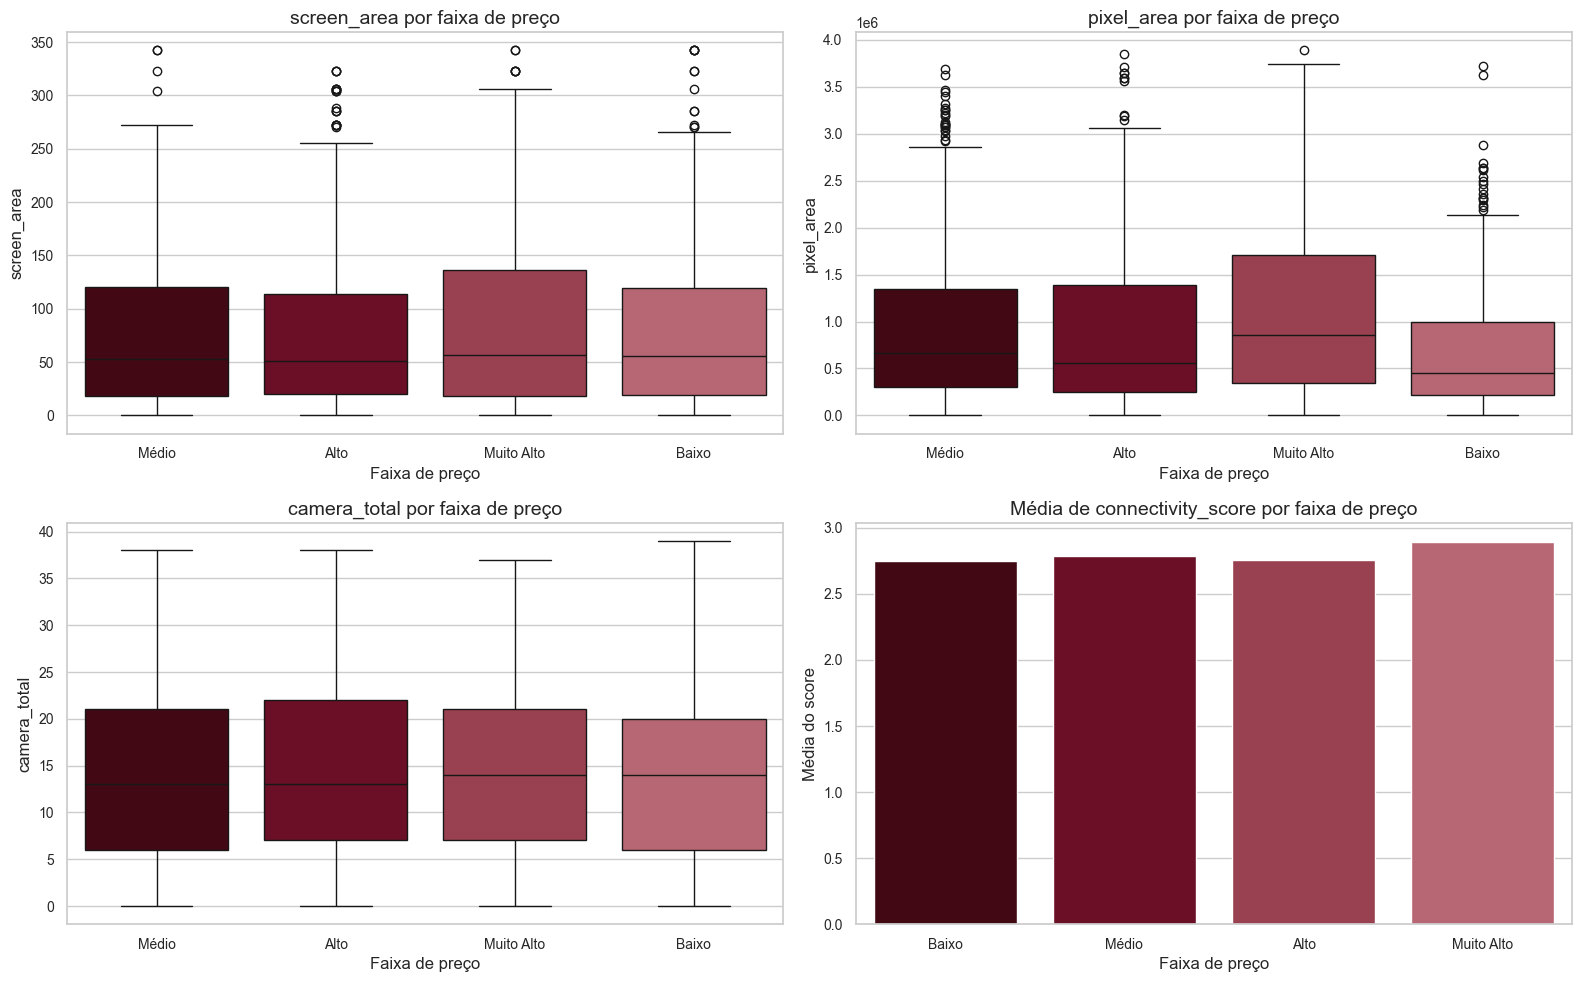

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(["screen_area", "pixel_area", "camera_total"]):
    sns.boxplot(
        data=df_eda,
        x="price_range_label",
        y=feature,
        hue="price_range_label",
        palette=dark_palette[:4],
        dodge=False,
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} por faixa de preço")
    axes[i].set_xlabel("Faixa de preço")
    axes[i].set_ylabel(feature)

connectivity_mean = (
    df_eda.groupby("price_range_label")["connectivity_score"]
    .mean()
    .reindex(ordered_labels)
    .reset_index()
)

sns.barplot(
    data=connectivity_mean,
    x="price_range_label",
    y="connectivity_score",
    hue="price_range_label",
    palette=dark_palette[:4],
    dodge=False,
    legend=False,
    ax=axes[3]
)
axes[3].set_title("Média de connectivity_score por faixa de preço")
axes[3].set_xlabel("Faixa de preço")
axes[3].set_ylabel("Média do score")

plt.tight_layout()
plt.show()

## análise das variáveis binárias

as variáveis binárias mostram a presença ou ausência de determinados recursos. nesta etapa, o foco é verificar se esses recursos aparecem com frequências diferentes entre as faixas de preço

,Baixo,Médio,Alto,Muito Alto
blue,48.6,49.0,48.6,51.8
dual_sim,50.0,51.0,49.8,53.0
four_g,51.8,52.4,49.4,55.0
three_g,74.6,75.6,77.4,77.0
touch_screen,52.4,52.2,47.0,49.6
wifi,49.6,50.4,50.4,52.4


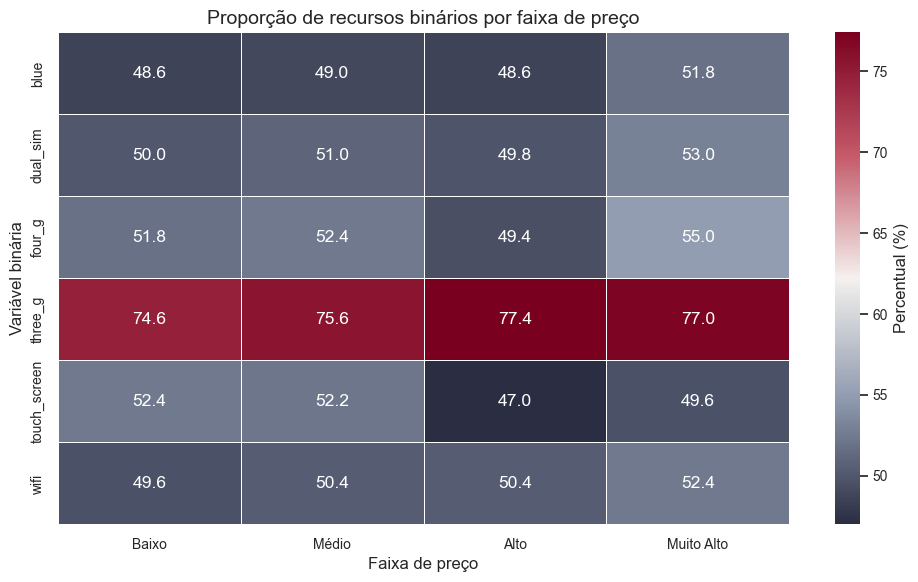

In [16]:
binary_features = ["blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi"]

binary_summary = df.groupby("price_range")[binary_features].mean().T
binary_summary.columns = ordered_labels
binary_summary_pct = (binary_summary * 100).round(1)

display(binary_summary_pct)

plt.figure(figsize=(10, 6))
sns.heatmap(
    binary_summary_pct,
    annot=True,
    fmt=".1f",
    cmap=cor,
    linewidths=0.5,
    cbar_kws={"label": "Percentual (%)"}
)
plt.title("Proporção de recursos binários por faixa de preço")
plt.xlabel("Faixa de preço")
plt.ylabel("Variável binária")
plt.tight_layout()
plt.show()

de forma geral, as variáveis binárias ajudam a complementar a descrição dos aparelhos, mas nem todas parecem separar com muita força as faixas de preço. recursos como `four_g` e `three_g` podem mostrar algum padrão, enquanto outros tendem a aparecer de forma mais distribuída entre as classes

## comparação das médias por faixa de preço

outra forma simples de comparar as classes é observar as médias das principais variáveis em cada faixa de preço

In [17]:
selected_features = [
    "ram",
    "battery_power",
    "px_height",
    "px_width",
    "int_memory",
    "mobile_wt",
    "talk_time"
]

class_mean_summary = df.groupby("price_range")[selected_features].mean().round(2)
class_mean_summary.index = ordered_labels

display(class_mean_summary)

,ram,battery_power,px_height,px_width,int_memory,mobile_wt,talk_time
Baixo,785.31,1116.90,536.41,1150.27,31.17,140.55,10.61
Médio,1679.49,1228.87,666.89,1251.91,32.12,140.51,11.36
Alto,2582.82,1228.32,632.28,1234.05,30.92,143.61,10.97
Muito Alto,3449.23,1379.98,744.85,1369.84,33.98,136.32,11.10


a tabela de médias costuma reforçar a impressão visual dos gráficos. se a média de `ram` cresce de forma consistente entre as classes, isso sugere uma relação forte com a variável alvo. bateria e resolução de tela também podem mostrar tendência de crescimento, enquanto peso, memória interna e tempo de conversação tendem a exigir uma leitura mais cuidadosa, já que a variação pode ser mais moderada

## matriz de correlação

a matriz de correlação permite observar relações lineares entre as variáveis. além da visão completa, faz sentido ordenar a correlação com `price_range` para identificar quais atributos parecem mais associados à variável alvo

,correlacao_com_price_range
price_range,1.000000
ram,0.917046
battery_power,0.200723
px_width,0.165818
px_height,0.148858
int_memory,0.044435
sc_w,0.038711
pc,0.033599
three_g,0.023611
sc_h,0.022986


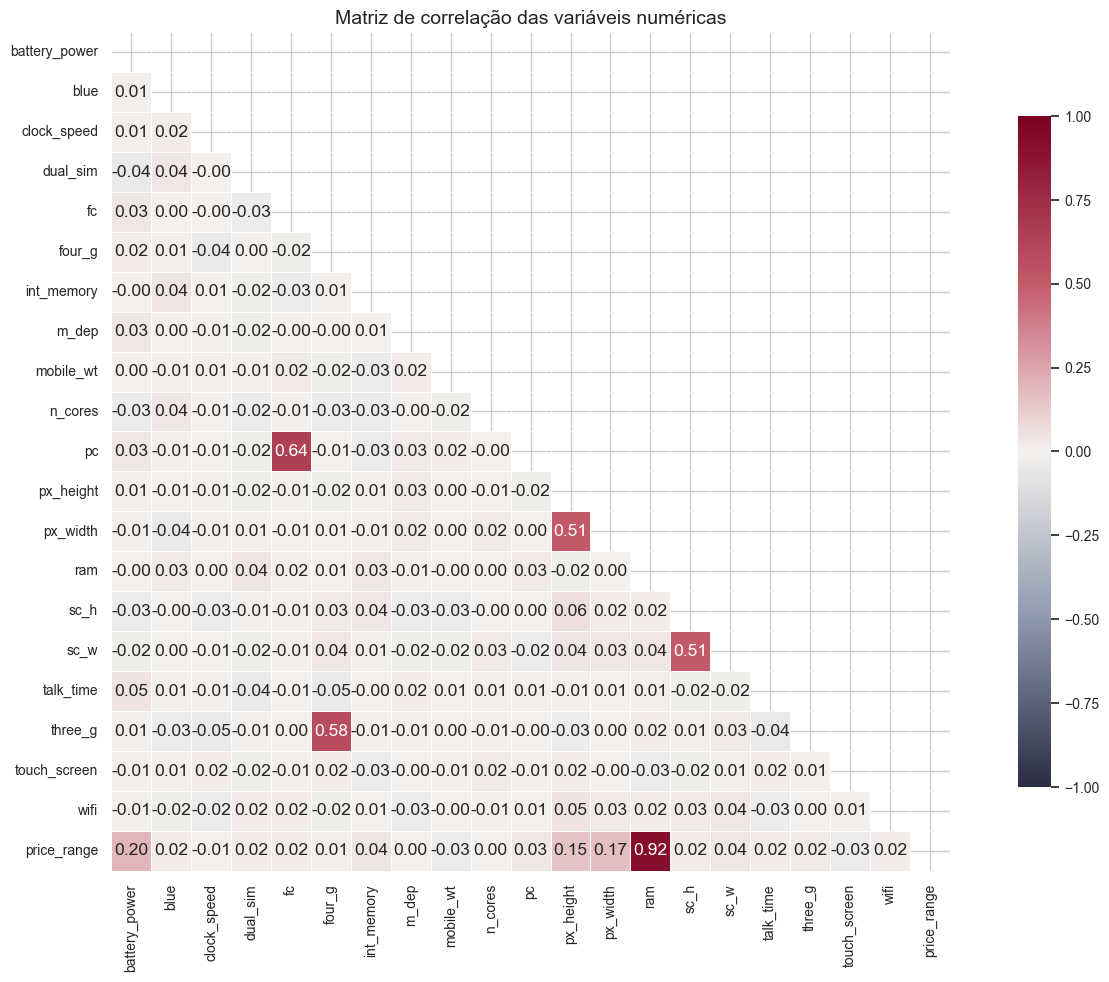

In [18]:
corr_matrix = df.corr(numeric_only=True)
price_corr = corr_matrix["price_range"].sort_values(ascending=False)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

display(price_corr.to_frame(name="correlacao_com_price_range"))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cor,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    square=True
)
plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

## ranking das correlações com a variável alvo

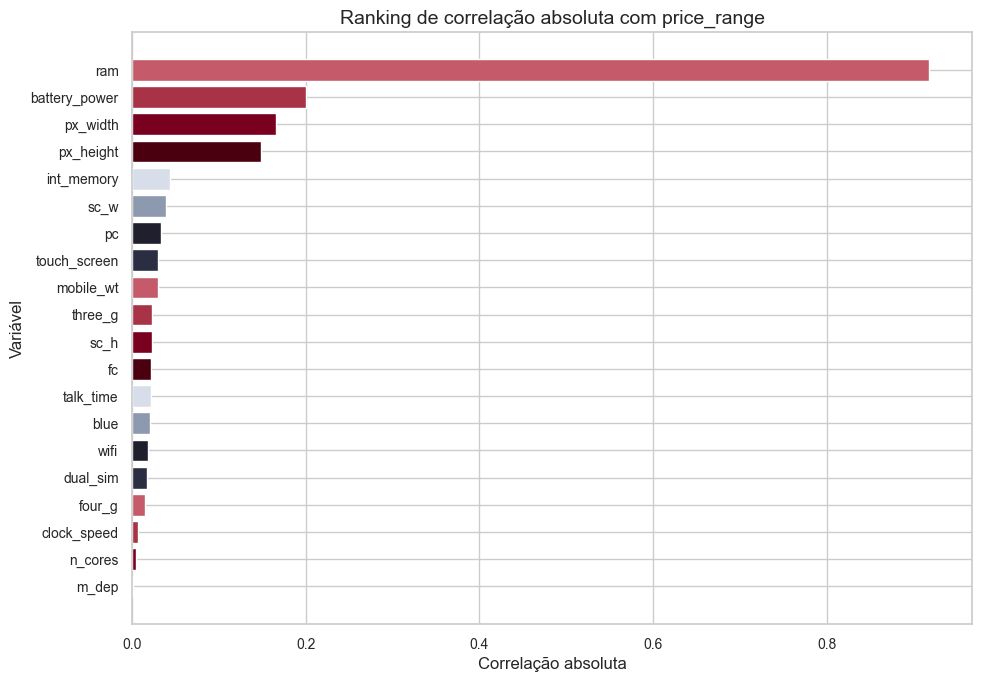

In [19]:
target_corr_abs = (
    df.corr(numeric_only=True)["price_range"]
    .drop("price_range")
    .abs()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
colors = [dark_palette[i % len(dark_palette)] for i in range(len(target_corr_abs))]
plt.barh(target_corr_abs.index, target_corr_abs.values, color=colors)
plt.title("Ranking de correlação absoluta com price_range")
plt.xlabel("Correlação absoluta")
plt.ylabel("Variável")
plt.xlim(0, target_corr_abs.max() + 0.05)
plt.tight_layout()
plt.show()

esse ranking sugere que `ram` é a variável mais relevante dentro da base original. em seguida, bateria e resolução da tela aparecem como sinais úteis, enquanto algumas variáveis binárias e atributos estruturais mostram correlações mais discretas

## análise de outliers

antes de modelar, também é útil verificar a presença de valores extremos. aqui, os outliers são contados com base no método do intervalo interquartil (IQR)

In [20]:
def count_outliers_iqr(data, columns):
    outlier_counts = []

    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        count = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()

        outlier_counts.append({
            "feature": col,
            "outliers": count,
            "percentual": round(count / len(data) * 100, 2)
        })

    return pd.DataFrame(outlier_counts).sort_values("outliers", ascending=False)

outlier_columns = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != "price_range" and df[col].nunique() > 2
]

outlier_summary = count_outliers_iqr(df, outlier_columns)
display(outlier_summary)

,feature,outliers,percentual
2,fc,18,0.9
8,px_height,2,0.1
0,battery_power,0,0.0
1,clock_speed,0,0.0
3,int_memory,0,0.0
4,m_dep,0,0.0
5,mobile_wt,0,0.0
6,n_cores,0,0.0
7,pc,0,0.0
9,px_width,0,0.0


nesta etapa, os outliers foram apenas analisados e não removidos automaticamente. a decisão de tratamento depende do contexto de negócio, da distribuição dos dados e do impacto que esses valores podem ter na modelagem

## verificação de inconsistências simples

algumas colunas merecem atenção especial quando apresentam valor zero, porque esse zero pode representar ausência real de recurso ou possível limitação na coleta da informação

In [21]:
zero_summary_all = pd.DataFrame({
    "quantidade_zero": (df == 0).sum(),
    "percentual_zero": ((df == 0).mean() * 100).round(2)
}).sort_values("percentual_zero", ascending=False)

display(zero_summary_all)

,quantidade_zero,percentual_zero
blue,1010,50.50
touch_screen,994,49.70
wifi,986,49.30
dual_sim,981,49.05
four_g,957,47.85
price_range,500,25.00
three_g,477,23.85
fc,474,23.70
sc_w,180,9.00
pc,101,5.05


substituir zeros por mediana
mesma coisa para o preço

In [22]:
zero_check_columns = ["px_height", "px_width", "sc_h", "sc_w", "fc", "pc"]

zero_summary = pd.DataFrame({
    "quantidade_zero": (df[zero_check_columns] == 0).sum(),
    "percentual_zero": ((df[zero_check_columns] == 0).mean() * 100).round(2)
})

display(zero_summary)

,quantidade_zero,percentual_zero
px_height,2,0.10
px_width,0,0.00
sc_h,0,0.00
sc_w,180,9.00
fc,474,23.70
pc,101,5.05


valores iguais a zero podem ter significados diferentes dependendo da variável. por exemplo, `fc = 0` pode indicar ausência de câmera frontal, enquanto `sc_w = 0` ou valores zerados em resolução pedem uma leitura mais cautelosa antes da modelagem

## análise da RAM por faixa de preço

como `ram` costuma ser uma das variáveis mais relevantes nesse dataset, vale observar sua distribuição com mais foco para entender o quanto ela ajuda a separar as classes

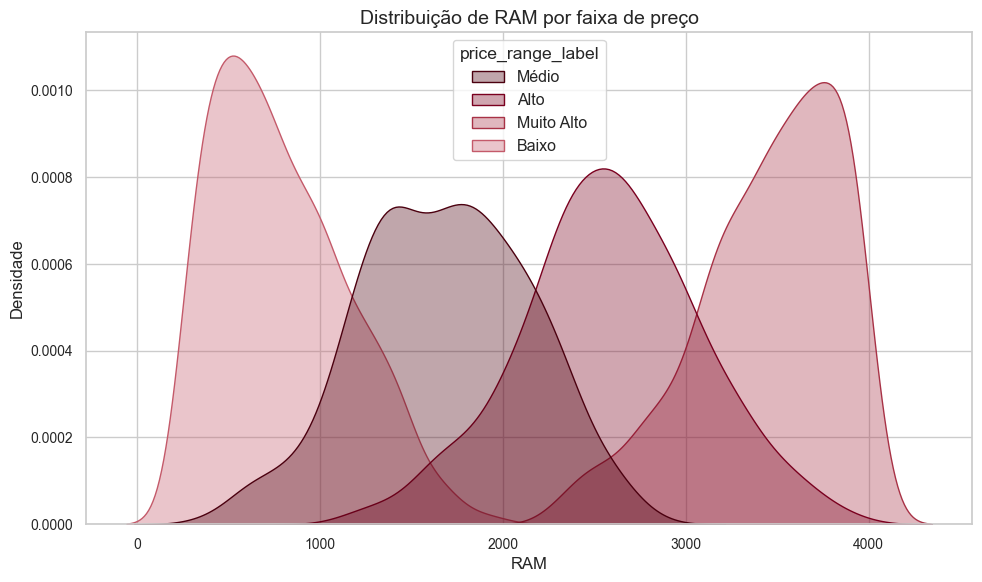

In [27]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_eda,
    x="ram",
    hue="price_range_label",
    fill=True,
    common_norm=False,
    palette=dark_palette[:4],
    alpha=0.35,
    warn_singular=False
)

plt.title("Distribuição de RAM por faixa de preço")
plt.xlabel("RAM")
plt.ylabel("Densidade")
plt.tight_layout()
plt.show()

a distribuição de `ram` tende a mostrar uma separação mais nítida entre as faixas de preço do que a maior parte das outras variáveis. isso reforça a ideia de que RAM deve ter papel importante na etapa de modelagem

## considerações da análise

alguns pontos se destacam a partir desta análise exploratória:

- o conjunto de dados parece bem estruturado, sem indícios relevantes de valores nulos ou duplicatas;
- a variável alvo `price_range` está balanceada, o que favorece a comparação entre modelos;
- `ram` aparece de forma consistente como uma das variáveis mais relacionadas à faixa de preço;
- bateria e resolução de tela também mostram sinais de utilidade para diferenciar classes;
- algumas variáveis binárias ajudam a compor o perfil dos aparelhos, mas parecem ter menor poder de separação isoladamente;
- valores zero e outliers foram analisados, mas não removidos automaticamente, já que essa decisão depende do contexto e do impacto esperado na modelagem;
- no conjunto, a EDA sugere quais variáveis podem ter maior relevância na etapa de classificação multiclasse.